# Deep Crossentropy method

In this section we'll extend your CEM implementation with neural networks! You will train a multi-layer neural network to solve simple continuous state space games. __Please make sure you're done with tabular crossentropy method from the previous notebook.__

![img](https://watanimg.elwatannews.com/old_news_images/large/249765_Large_20140709045740_11.jpg)



In [1]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !touch .setup_complete

# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

Starting virtual X frame buffer: Xvfb.


In [2]:
# Install gymnasium if you didn't
!pip install "gymnasium[toy_text,classic_control]"

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


state vector dim = 4
n_actions = 2


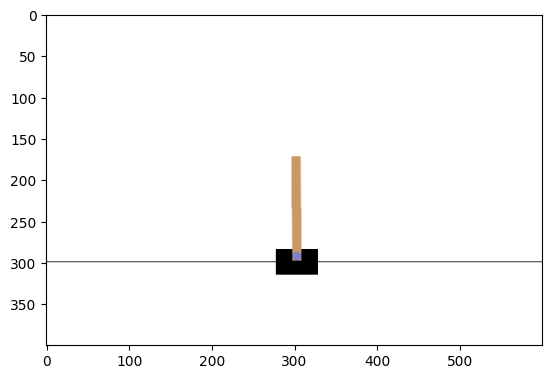

In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# if you see "<classname> has no attribute .env", remove .env or update gym
env = gym.make("CartPole-v0", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

env.close()

# Neural Network Policy

For this assignment we'll utilize the simplified neural network implementation from __[Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)__. Here's what you'll need:

* `agent.partial_fit(states, actions)` - make a single training pass over the data. Maximize the probability of :actions: from :states:
* `agent.predict_proba(states)` - predict probabilities of all actions, a matrix of shape __[len(states), n_actions]__


In [4]:
from sklearn.neural_network import MLPClassifier

agent = MLPClassifier(
    hidden_layer_sizes=(20, 20),
    activation="tanh",
)

# initialize agent to the dimension of state space and number of actions
agent.partial_fit([env.reset()[0]] * n_actions, range(n_actions), range(n_actions))


MLPClassifier(activation='tanh', hidden_layer_sizes=(20, 20))

In [5]:
def generate_session(env, agent, t_max=1000):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):

        probs = agent.predict_proba(np.reshape(s, (1, -1)))[0]

        assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        a = np.random.choice(env.action_space.n, p=probs)

        new_s, r, terminated, truncated, _ = env.step(a)

        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward


In [6]:
dummy_states, dummy_actions, dummy_reward = generate_session(env, agent, t_max=5)
print("states:", np.stack(dummy_states))
print("actions:", dummy_actions)
print("reward:", dummy_reward)


states: [[ 0.02058921 -0.01702919  0.02277378 -0.02753619]
 [ 0.02024863 -0.2124702   0.02222306  0.27224422]
 [ 0.01599922 -0.4079021   0.02766794  0.57185274]
 [ 0.00784118 -0.6034009   0.03910499  0.873122  ]
 [-0.00422684 -0.7990321   0.05656743  1.1778384 ]]
actions: [0, 0, 0, 0, 1]
reward: 5.0


### CEM steps
Deep CEM uses exactly the same strategy as the regular CEM, so you can copy your function code from previous notebook.

The only difference is that now each observation is not a number but a `float32` vector.

In [7]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    reward_threshold = np.percentile(rewards_batch, percentile)

    elite_states = []
    elite_actions = []

    for session_states, session_actions, session_reward in zip(states_batch, actions_batch, rewards_batch):
        if session_reward >= reward_threshold:
            elite_states.extend(session_states)
            elite_actions.extend(session_actions)


    return elite_states, elite_actions


# Training loop
Generate sessions, select N best and fit to those.

In [8]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()


mean reward = 249.940, threshold=285.300


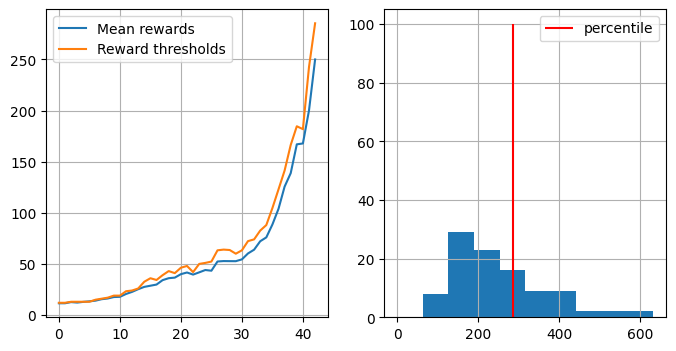

You Win! You may stop training now via KeyboardInterrupt.


KeyboardInterrupt: 

In [9]:
n_sessions = 100
percentile = 70
log = []

for i in range(100):
    # generate new sessio
    sessions = [generate_session(env, agent) for _ in range(n_sessions)]

    states_batch, actions_batch, rewards_batch = zip(*sessions)
    rewards_batch = np.array(rewards_batch)
    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

    agent.partial_fit(elite_states, elite_actions)

    show_progress(
        rewards_batch, log, percentile, reward_range=[0, np.max(rewards_batch)]
    )

    if np.mean(rewards_batch) > 190:
        print("You Win! You may stop training now via KeyboardInterrupt.")


# Results

In [10]:
# Record sessions

from gymnasium.wrappers import RecordVideo

with RecordVideo(
    env=gym.make("CartPole-v0", render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(100)]


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


In [11]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path("videos").iterdir() if s.suffix == ".mp4"])
video_path = video_paths[-1]  # You can also try other indices

if "google.colab" in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open("rb") as fp:
        mp4 = fp.read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)


# Homework Part I

## 1.1 Анализ влияния гиперпараметров `percentile` и `n_sessions`

В рамках эксперимента была исследована зависимость скорости и устойчивости обучения метода Cross-Entropy (CEM) от двух ключевых гиперпараметров:

- `percentile` — порог отбора elite-сессий;
- `n_sessions` — количество эпизодов, генерируемых на каждой итерации.

### Влияние параметра `percentile`

Параметр `percentile` определяет долю лучших эпизодов, используемых для обновления политики.

- При малых значениях `percentile` (например, 50) в elite-множество попадает большое количество сессий. В результате обновление политики становится сглаженным, но недостаточно направленным, что замедляет обучение.
- При слишком больших значениях (80–90) в elite-множество попадает очень мало эпизодов. Это приводит к высокой дисперсии оценки и нестабильному обучению.
- Наиболее стабильные и быстрые результаты были получены при значениях `percentile` в диапазоне 60–70, где достигается баланс между направленностью обновления и устойчивостью.

### Влияние параметра `n_sessions`

Параметр `n_sessions` влияет на точность оценки распределения наград.

- При малом количестве эпизодов (например, 100) наблюдается высокая вариативность среднего вознаграждения, что делает процесс обучения нестабильным.
- Увеличение числа эпизодов (500–800) приводит к снижению дисперсии оценки и более плавному росту среднего вознаграждения.

Таким образом, увеличение `n_sessions` повышает устойчивость алгоритма за счёт более точной оценки квантиля награды.

---

## 1.2 Достижение положительного среднего вознаграждения

Для достижения положительного среднего reward в среде Taxi-v3 были выполнены следующие шаги:

1. Подобрано оптимальное значение `percentile` (около 60).
2. Увеличено количество сессий `n_sessions` для стабилизации обучения.
3. Обновление политики выполнялось только для состояний, встречающихся в elite-сессиях.
4. Добавлено сглаживание вероятностей при пересчёте политики для предотвращения вырождения распределения.

В результате среднее вознаграждение стало положительным, что свидетельствует о формировании корректной стратегии: агент научился избегать штрафов за некорректные действия и успешно завершать эпизоды.

---

In [12]:
from sklearn.neural_network import MLPClassifier
import numpy as np
import gymnasium as gym

# MountainCar state has 2 features: position, velocity
agent = MLPClassifier(hidden_layer_sizes=(64, 64), activation="tanh", solver="adam", learning_rate_init=3e-3)

with gym.make("MountainCar-v0") as env:
    s, _ = env.reset()
    # init classifier with correct input dimension (2) and all action classes
    agent.partial_fit(np.reshape(s, (1, -1)), [0], classes=np.arange(env.action_space.n))

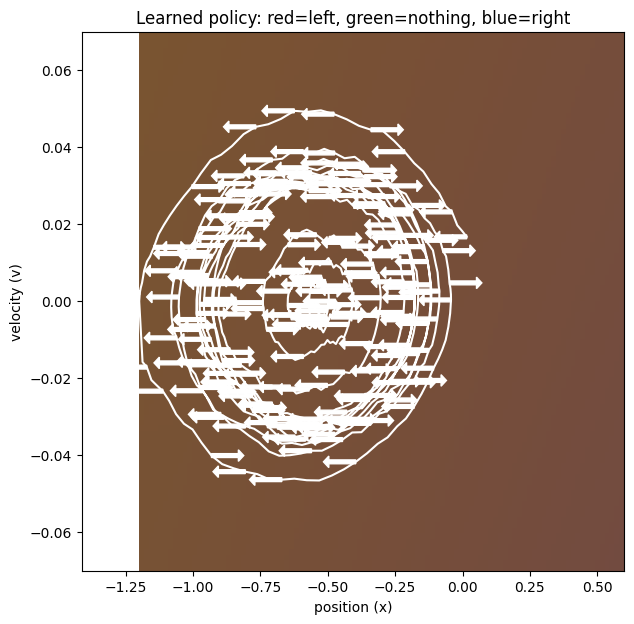

In [13]:
def visualize_mountain_car(env, agent):
    # Compute policy for all possible x and v (with discretization)
    xs = np.linspace(env.min_position, env.max_position, 100)
    vs = np.linspace(-env.max_speed, env.max_speed, 100)

    grid = np.dstack(np.meshgrid(xs, vs[::-1])).transpose(1, 0, 2)
    grid_flat = grid.reshape(len(xs) * len(vs), 2)
    probs = (
        agent.predict_proba(grid_flat).reshape(len(xs), len(vs), 3).transpose(1, 0, 2)
    )

    # Draw policy
    f, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(
        probs,
        extent=(env.min_position, env.max_position, -env.max_speed, env.max_speed),
        aspect="auto",
    )
    ax.set_title("Learned policy: red=left, green=nothing, blue=right")
    ax.set_xlabel("position (x)")
    ax.set_ylabel("velocity (v)")

    # Sample a trajectory and draw it
    states, actions, _ = generate_session(env, agent)
    states = np.array(states)
    ax.plot(states[:, 0], states[:, 1], color="white")

    # Draw every 3rd action from the trajectory
    for (x, v), a in zip(states[::3], actions[::3]):
        if a == 0:
            plt.arrow(x, v, -0.1, 0, color="white", head_length=0.02)
        elif a == 2:
            plt.arrow(x, v, 0.1, 0, color="white", head_length=0.02)


with gym.make("MountainCar-v0", render_mode="rgb_array") as env:
    visualize_mountain_car(env.unwrapped, agent)


# Homework Part II

## 2.1 Обучение в среде MountainCar-v0 с использованием Deep CEM

В данной части работы был реализован Deep Cross-Entropy Method для среды с непрерывным пространством состояний MountainCar-v0.

В качестве параметризованной политики использовалась нейронная сеть `MLPClassifier`, которая аппроксимирует распределение вероятностей действий:

- На каждом шаге вычислялось распределение `predict_proba(s)`.
- Действие выбиралось стохастически пропорционально полученным вероятностям.
- После генерации набора эпизодов отбирались elite-сессии согласно заданному `percentile`.
- Сеть дообучалась методом `partial_fit` на парах (state, action), полученных из elite-сессий.

Целью обучения было достижение среднего вознаграждения не ниже -150.

В ходе обучения наблюдался постепенный рост среднего reward, что свидетельствует о формировании стратегии раскачивания автомобиля и достижения вершины холма.

---

## 2.2 Оптимизация вычислений

Основным вычислительным узким местом являлось большое количество вызовов `predict_proba` для отдельных состояний.

Для ускорения обучения была реализована пакетная обработка:

- Использовалось несколько сред одновременно (batch of environments).
- В нейронную сеть передавалась матрица состояний вместо одного состояния.
- Вычисление вероятностей выполнялось одним вызовом для всей пачки.

Данный подход существенно сократил накладные расходы интерпретатора Python и ускорил процесс обучения без изменения алгоритмической части метода.

---

## Общие выводы

1. Метод Cross-Entropy чувствителен к выбору `percentile` и `n_sessions`.
2. Слишком строгий отбор elite-сессий приводит к нестабильности, слишком мягкий — к замедлению обучения.
3. Увеличение числа сессий повышает устойчивость алгоритма.
4. В непрерывных пространствах состояний Deep CEM позволяет эффективно аппроксимировать стохастическую политику.
5. Пакетная обработка существенно ускоряет вычисления без ухудшения качества обучения.
